# Beta Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Nazhin Nikkhahbahrami

*SID:* 810102530

The objective of this notebook is to estimate the probability of getting tails in a coin flip using a Bayesian approach.



In [82]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from scipy.special import gammaln
import math

In [83]:
class BetaDistribution:
    """
    Represents a beta distribution with the given shape parameters.
    """

    def __init__(self, alpha: float, beta: float):
        """
        Args:
            alpha (float): The first shape parameter of the beta distribution.
            beta (float): The second shape parameter of the beta distribution.
        """

        ######################  TODO  ########################
        self.alpha = alpha
        self.beta = beta
        ######################  TODO  ########################

    def pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the normalized probability density function (PDF) of the beta distribution at the given input value(s).
        Args:
            x (float or np.ndarray): The input value(s) to evaluate the beta distribution PDF at.
        Returns:
            pdf (float or np.ndarray): The normalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        normalization_constant = self.__calculate_normalization_constant()
        unnormalized_pdf = self.__unnormalized_pdf(x)
        return unnormalized_pdf / normalization_constant
        ######################  TODO  ########################

    def __unnormalized_pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the unnormalized probability density function (PDF) of the beta distribution at the given input value(s).

        Args:
            x (float or np.ndarray): The input value(s) to evaluate the unnormalized beta distribution PDF at.

        Returns:
            pdf (float or np.ndarray): The unnormalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        return x**(self.alpha - 1) * (1 - x)**(self.beta - 1)
        ######################  TODO  ########################

    def __calculate_normalization_constant(self):
        """
        Calculates the normalization constant for the beta distribution.
        This constant is used to ensure that the total probability under the PDF is 1.
        """
        ######################  TODO  ########################
        # Proceed with the numerical approach
        a=gammaln(self.alpha)
        b=gammaln(self.beta)
        c=gammaln(self.alpha+self.beta)
        return np.exp(a+b-c)
        ######################  TODO  ########################

chon az tabe beta nemitavan estefade kard va meghdar ha ziad hastand, az tarif antegrali estefade kardim.

In [84]:
def plot_beta_dist(beta: BetaDistribution):
    """
    Plots the probability density function of the given beta distribution.

    Args:
        beta (BetaDistribution): The beta distribution instance to plot.
    """
    ######################  TODO  ########################
    # Do not forget to add title, labels, and legend.
    x = np.linspace(0, 1, 500)
    plt.plot(x, beta.pdf(x), label=f"Beta({beta.alpha}, {beta.beta})")
    plt.title("Beta Distribution")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    ######################  TODO  ########################

Read the `coint_flips.txt` file and plot the posterior distributions after every 50 trials for two prior probabilities:
1. Uniform distribution 
2. $Beta (4, 10)$

In [85]:
######################  TODO  ########################
# Read coin_flips.txt
with open("data/coin_flips.txt","r") as file:
    coin_flips = list(file.read().replace('\n','').strip())
######################  TODO  ########################

## Prior: Uniform

**Hint:** use `plt.figure(figsize=(25, 20))` and `plt.subplot(4, 5, ...)`

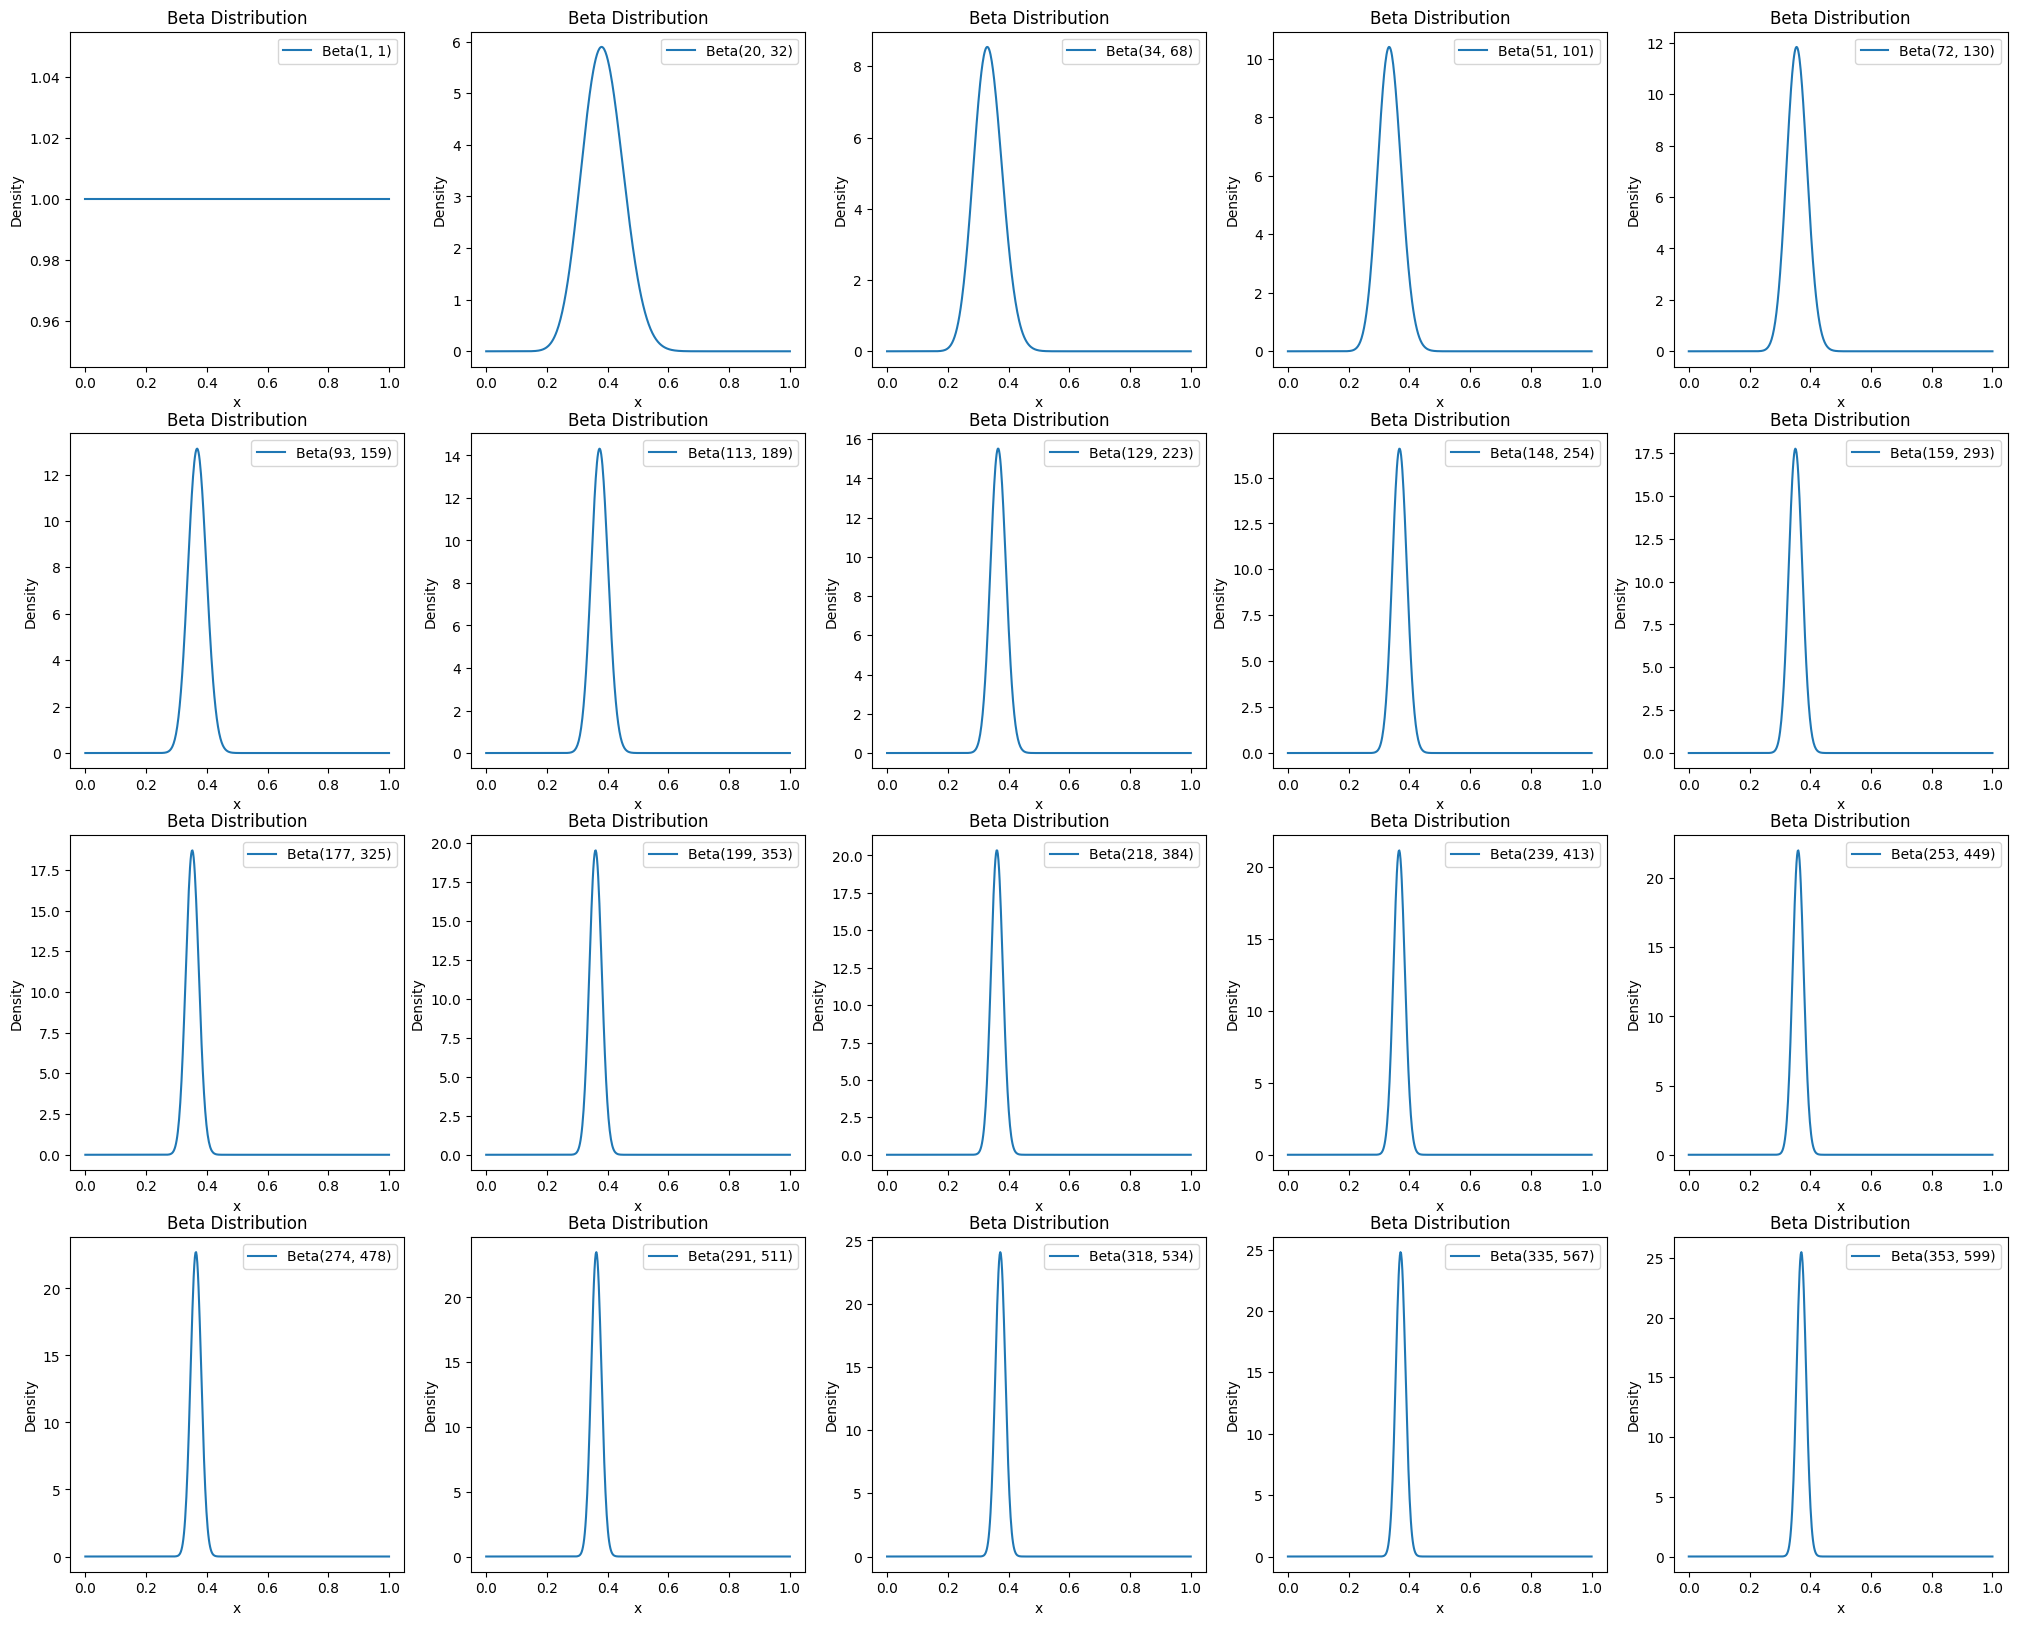

In [86]:
######################  TODO  ########################
head_uniform=1
tale_uniform=1
plt.figure(figsize=(25,20))
plot_index=1
plt.subplot(4,5,plot_index)
prior_uniform = BetaDistribution(head_uniform, tale_uniform)
plot_beta_dist(prior_uniform)
count = 0
for coin in coin_flips:
    if count < 50 :
        if coin == 'H':
            head_uniform += 1
        else:   
            tale_uniform += 1
        count += 1
    else :
        plot_index+=1
        plt.subplot(4,5,plot_index)
        prior_uniform= BetaDistribution(head_uniform, tale_uniform)
        plot_beta_dist(prior_uniform)
        count = 0
######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [87]:
######################  TODO  ########################
mean_uniform_1 = head_uniform / (head_uniform + tale_uniform)
variance_uniform_1 = (head_uniform * (head_uniform+1)) / ((head_uniform + tale_uniform)*(head_uniform+tale_uniform+1))
print(mean_uniform_1)
print(variance_uniform_1)
######################  TODO  ########################

0.36826042726347913
0.13585216981366152


ba tavajoh be algorithm mean va variance beta khodeman ba hasb moteghayer ha tarif kardim. mishod ba numpy az tabe amade niz estefade kard

## Prior: $Beta(4, 10)$

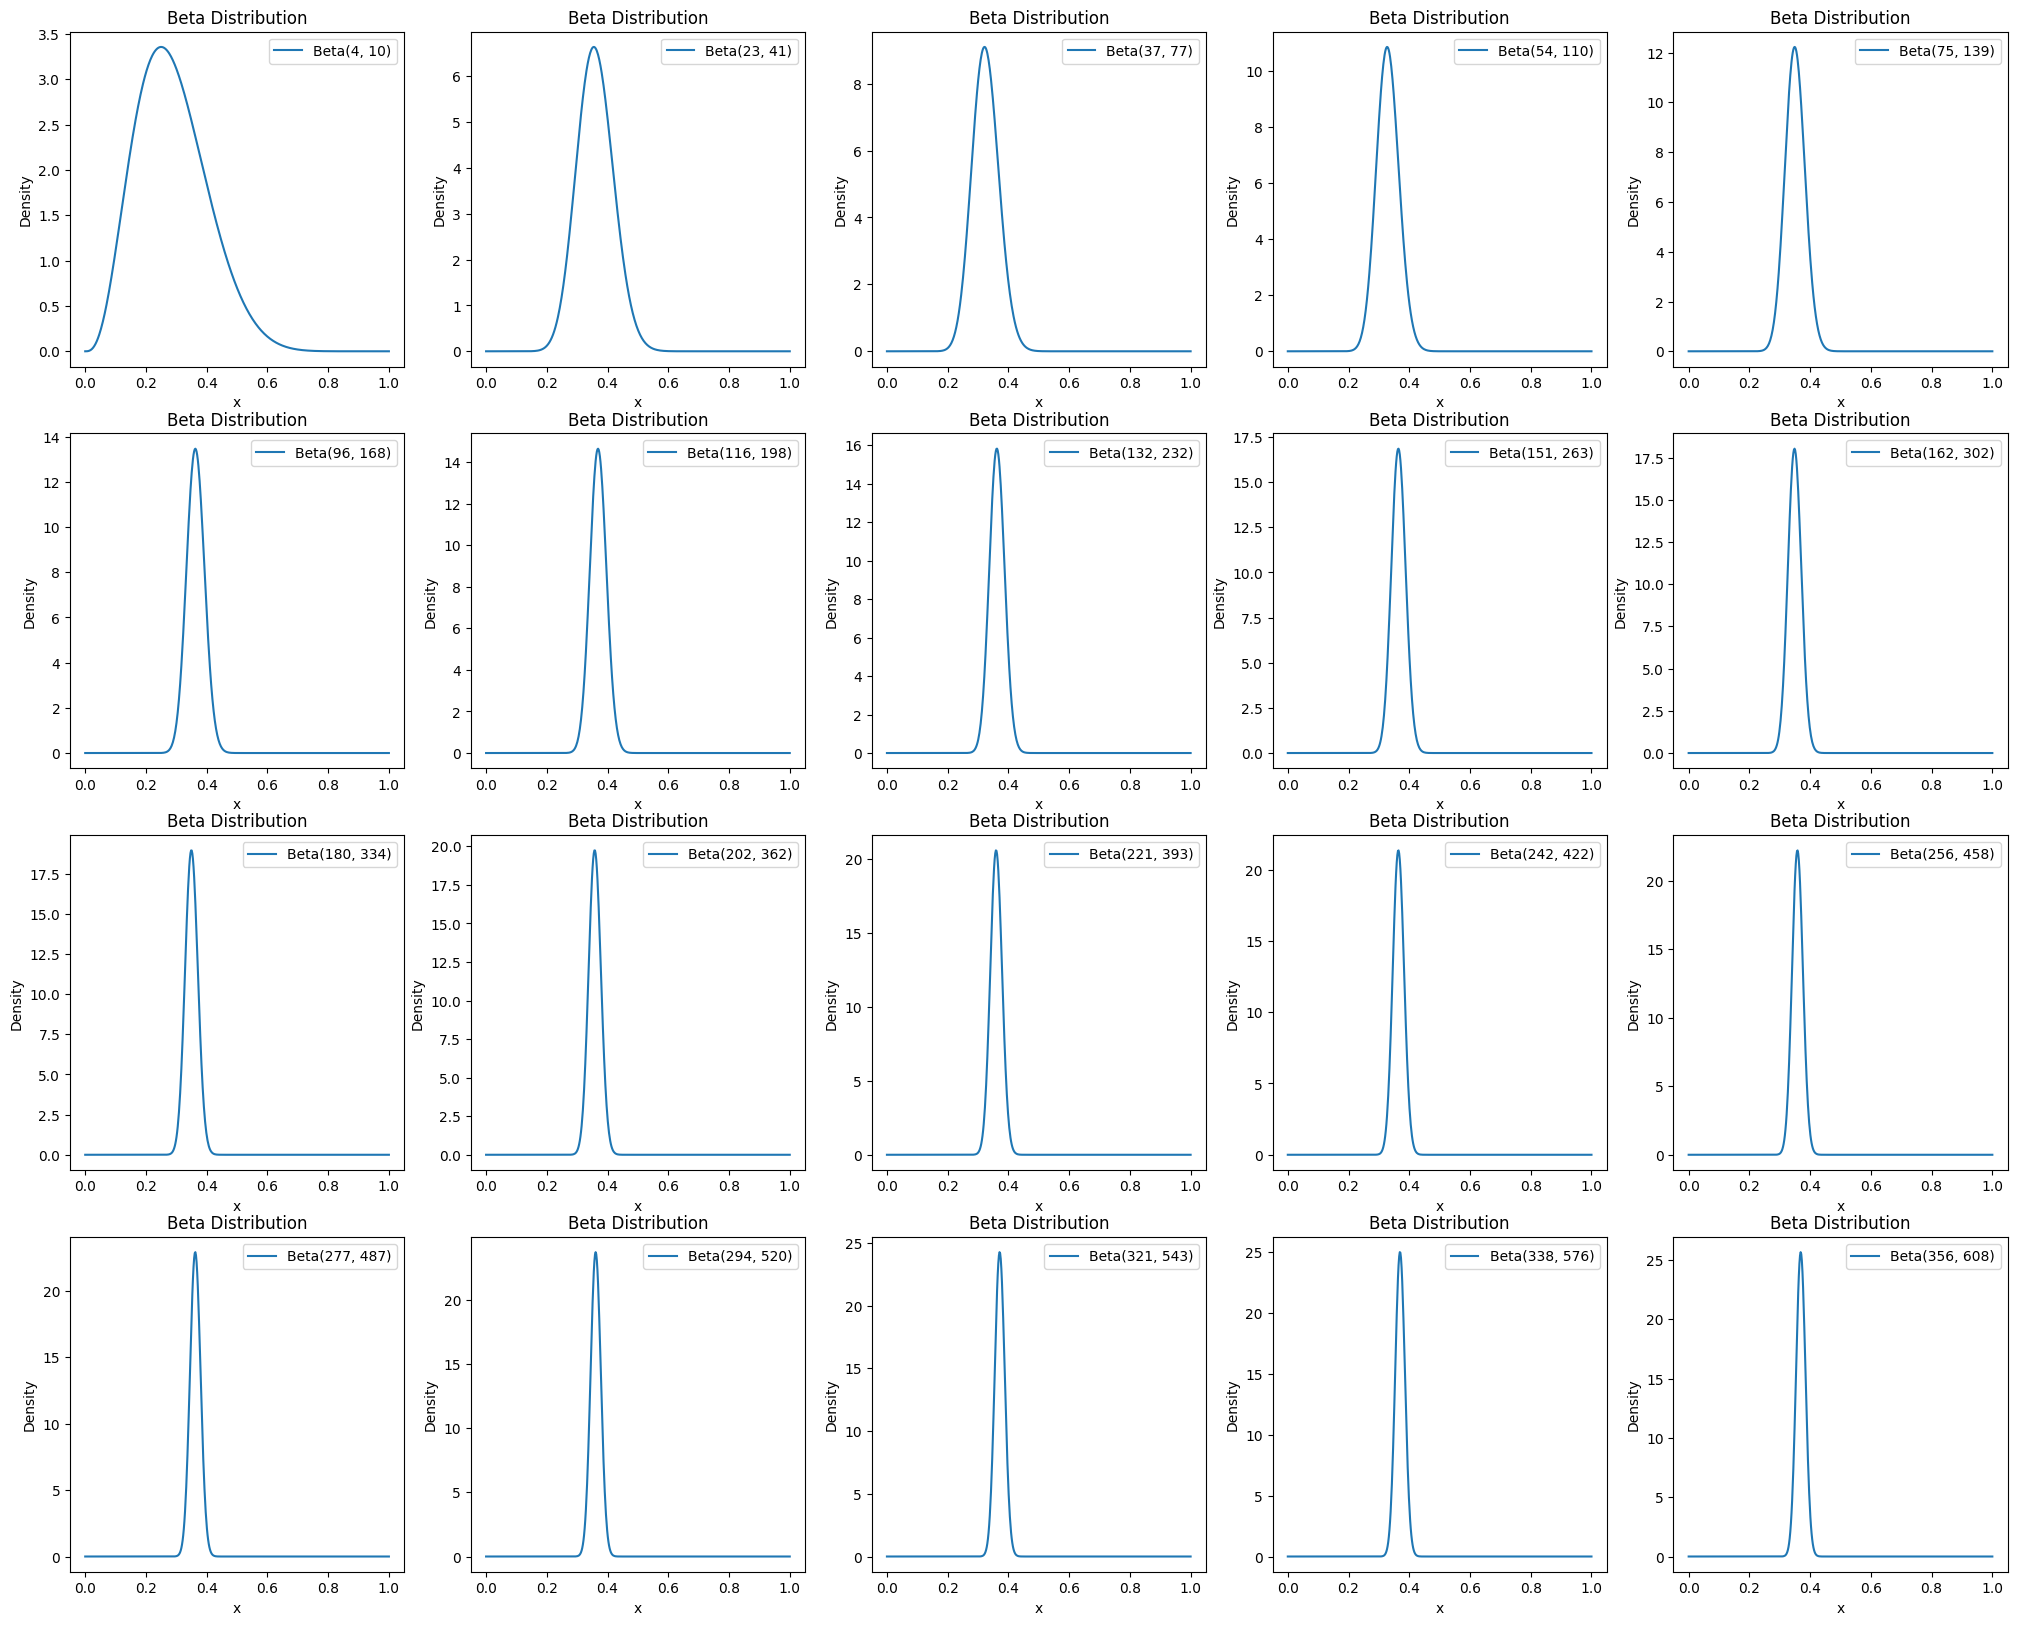

In [88]:
######################  TODO  ########################
head_uniform=4
tale_uniform=10
plt.figure(figsize=(25,20))
plot_index=1
plt.subplot(4,5,plot_index)
prior_uniform = BetaDistribution(head_uniform, tale_uniform)
plot_beta_dist(prior_uniform)
count = 0
for coin in coin_flips:
    if count < 50 :
        if coin == 'H':
            head_uniform += 1
        else:   
            tale_uniform += 1
        count += 1
    else :
        plot_index+=1
        plt.subplot(4,5,plot_index)
        prior_uniform= BetaDistribution(head_uniform, tale_uniform)
        plot_beta_dist(prior_uniform)
        count = 0
######################  TODO  ########################

hamantor ke moshahede mishavad,ba afzayesh tedad azmayesh be adad mean nazdik mishavim(hodudan haman 0.4 theorical ast). dar ebteda ke 1,1 bood baray hame halat yek khat saf didim ama bad nemudar tiz shode be samt 

Now calculate the final posterior mean and variance.

In [89]:
######################  TODO  ########################
mean_uniform_2 = head_uniform / (head_uniform + tale_uniform)
variance_uniform_2 = (head_uniform * tale_uniform) / (((head_uniform + tale_uniform)**2)*(head_uniform+tale_uniform+1))
print (mean_uniform_2)
print(variance_uniform_2)
######################  TODO  ########################

0.36683417085427134
0.00023319966059029177


natije moghayese:chon tedad azmayesh 1000 bar ast meghdar avalie digar tasiri nadarad va mean va variance ba ham taghriban barabar hastand. dar vaghe beysian zamani tafavot darad ke tedad azmayesh va tekrar kam bashad va meghdar avalie baray ma mohem ast.